In [24]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [38]:
from simulations_mod.wrapper import simulator

## templates and masks

In [27]:
nside = 128
band_mask_range = 2.
r_outer = 25.

# mask
mask_plane = cm.make_mask_total(
    nside=nside,
    band_mask=True,
    band_mask_range=band_mask_range,
    mask_ring=True,
    inner=0,
    outer=r_outer,
)
m = normalization_mask = mask_plane

# templates
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)
temp_dict = {
    'gce' : nfw_template.get_NFW2_template(gamma=1.2),
    'dsk' : disk_template.get_template(zs=0.5, C=2.5),
}
for k in temp_dict.keys():
    temp_dict[k] /= np.mean(temp_dict[k][~m])

## truth

In [28]:
vd_base = dict(
    Sps_dsk = None,
    Sps_gce = None,
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
)

In [29]:
run_name = data_dir = "dsk_gce_deltapsf_oldsim"
os.makedirs(data_dir, exist_ok=True)

vd = vd_base.copy()
vd['Sps_dsk'] = 1.
vd['Sps_gce'] = 2.
pickle.dump(vd, open(f"{data_dir}/truth.p", 'wb'))

## modified old sim

In [30]:
temps_poiss = [np.ones_like(temp_dict['gce'], dtype=float)]
theta = [1e-10]

temps_ps = []
for k in ['gce', 'dsk']:
    if vd['Sps_'+k] > 0:
        temps_ps.append(np.array(temp_dict[k]))
        # theta[0] should be expected photon count per pixel in normalization mask region
        theta += [vd['Sps_'+k], vd['n1_'+k], vd['n2_'+k], vd['n3_'+k], vd['sb1_'+k], vd['lambdas_'+k] * vd['sb1_'+k]]

mask_sim = m
mask_normalize_counts = m
mask_roi = m

# delta_psf, shouldn't matter
sigma = np.deg2rad(0.001) / 3
psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)

exp_map = np.ones_like(temp_dict['gce'], dtype=float)

In [35]:
a = np.array([1, 2, 3])
np.add.at(a, [], 1)
a

array([1, 2, 3])

In [47]:
np.rad2deg(hp.nside2resol(128))

0.45806485490898746

In [43]:
z = simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, psf_r_func, exp_map)[0]

drawn ps: 6524
3 0.3333333333333333
3 0.3333333333333333
8 0.375
5 0.6
6 0.8333333333333334
12 0.9166666666666666
2 0.0
2 0.5
4 0.75
5 0.8
2 0.5
9 0.6666666666666666
8 0.75
2 0.5
3 0.6666666666666666
n_pix_out: 15
n_phot_out: 26
drawn ps: 2465
10 0.8
15 0.6
5 0.8
5 0.8
11 0.8181818181818182
15 0.6
6 0.8333333333333334
7 0.7142857142857143
12 0.4166666666666667
n_pix_out: 9
n_phot_out: 28


In [44]:
np.sum(z)

24221.0

In [14]:
n_sim = 50

data_s = []
for _ in tqdm(range(n_sim)):
    data_s.append(simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, psf_r_func, exp_map)[0])
data_s = np.array(data_s)

100%|██████████| 50/50 [04:09<00:00,  4.99s/it]


In [23]:
np.save(data_dir + "/data_s.npy", data_s)

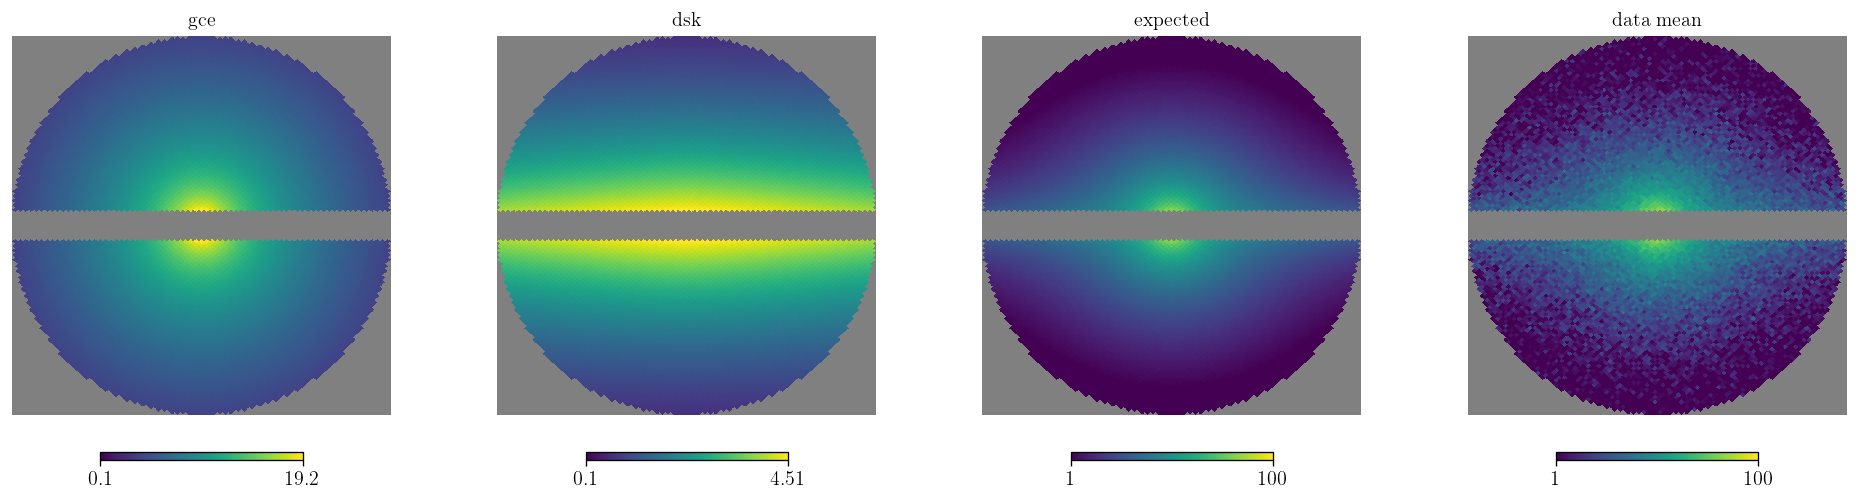

In [21]:
# validate
npix = hp.nside2npix(nside)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

plt.sca(axs[0])
z = np.zeros(npix)
z[~m] = temp_dict['gce'][~m]
hp.cartview(z, latra=[-25,25], lonra=[-25,25], hold=True, title='gce', norm='log', min=1e-1)

plt.sca(axs[1])
z = np.zeros(npix)
z[~m] = temp_dict['dsk'][~m]
hp.cartview(z, latra=[-25,25], lonra=[-25,25], hold=True, title='dsk', norm='log', min=1e-1)

plt.sca(axs[2])
z = np.zeros(npix)
z[~m] = temp_dict['gce'][~m] * vd['Sps_gce'] + temp_dict['dsk'][~m] * vd['Sps_dsk']
hp.cartview(z, latra=[-25,25], lonra=[-25,25], hold=True, title='expected', norm='log', min=1, max=1e2)

plt.sca(axs[3])
z = np.zeros(npix)
z[~m] = np.mean(data_s[:,~m], axis=0)
hp.cartview(z, latra=[-25,25], lonra=[-25,25], hold=True, title='data mean', norm='log', min=1, max=1e2)

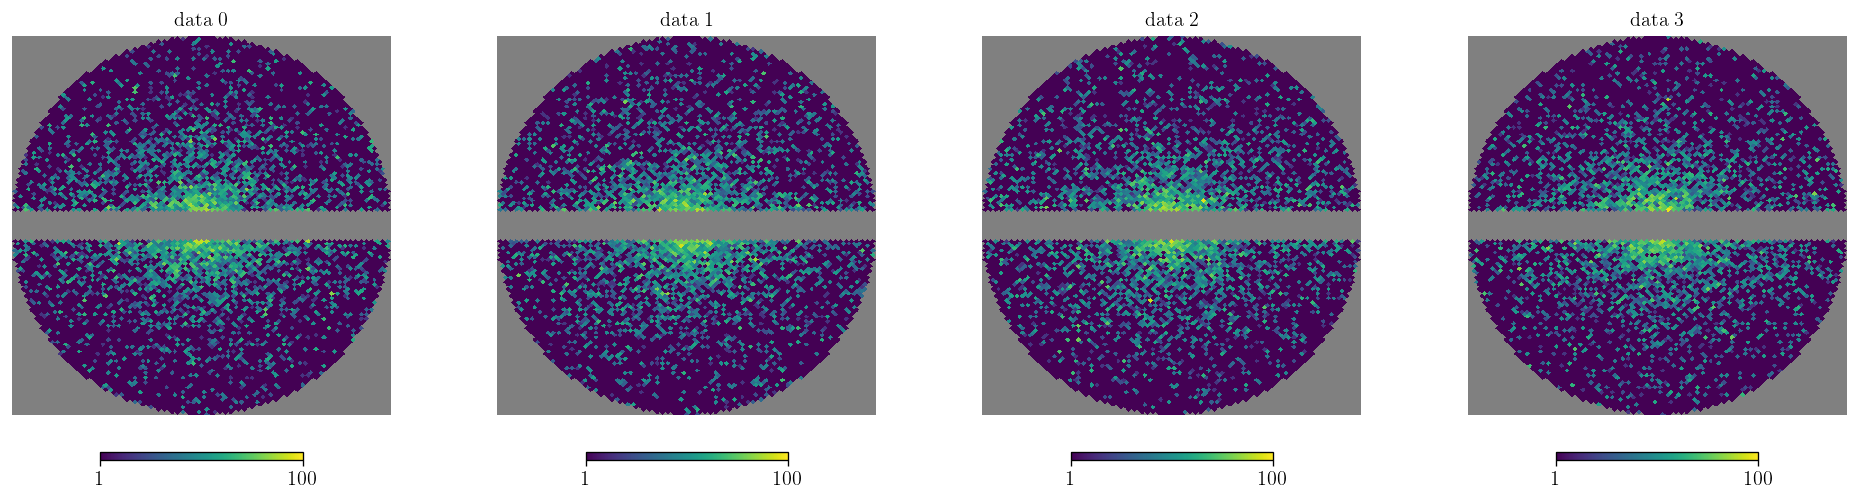

In [22]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    plt.sca(axs[i])
    z = np.zeros(npix)
    z[~m] = np.clip(data_s[i][~m], 0.5, None)
    hp.cartview(z, latra=[-25,25], lonra=[-25,25], hold=True, title=f'data {i}', norm='log', min=1, max=1e2)